In [3]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import sys
import os

project_root = Path.cwd().resolve()
# Notebook lives at models/nba/ — climb to repo root if needed
if not (project_root / "data").exists():
    project_root = project_root.parent.parent

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)
os.chdir(project_root_str)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [10]:
from src.pipeline.features.context_features import ContextFeatureEngineer

seasons = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
frames = []
for yr in seasons:
    path = f"data/processed/{yr}_Regular_Season_training_data.parquet"
    season_df = pd.read_parquet(path)
    season_df = ContextFeatureEngineer(league="nba").enrich(season_df)
    frames.append(season_df)

df = pd.concat(frames, ignore_index=True)
df.sample(10)



Context features (pos, rest, trends, ranks, std/var, games played)

Merging player positions...
  loaded 554 positions from nba_2021_players.csv (season=2020-21)
  pos filled on 22,950 / 23,054 rows (1 season file(s))

Adding games_played to date...
  games_played + season_games_played

Adding rest / back-to-back...
  days_rest + is_back_to_back (4,202 B2B rows)

Adding fatigue window features...
  games_played_last_7/14_days + min_sum_last_7_days (from minutes)

Adding 5v20 trends...
  added 7 trend cols: ['base_min_trend_5v20', 'base_pts_per_min_trend_5v20', 'adv_ts_pct_trend_5v20', 'adv_usg_pct_trend_5v20', 'base_ast_per_min_trend_5v20', 'base_oreb_per_min_trend_5v20', 'base_dreb_per_min_trend_5v20']

Adding within-team ranks...
  added 7 rank cols: ['team_pts_per_min_rank_l10', 'team_ast_per_min_rank_l10', 'team_oreb_per_min_rank_l10', 'team_dreb_per_min_rank_l10', 'team_ts_pct_rank_l10', 'team_usg_pct_rank_l10', 'team_min_rank_l10']

Adding rolling team rank for pts_per_min (L10)

,game_id,player_id,team_id,player_name,game_date,season_year,matchup,minutes,pts_per_min,fga_per_min,fg3a_per_min,fta_per_min,oreb_per_min,dreb_per_min,reb_per_min,ast_per_min,tov_per_min,stl_per_min,blk_per_min,blka_per_min,games_played,base_min_ewm_hl5,base_min_ewm_hl10,base_min_ewm_hl20,base_min_lag1,base_min_season_avg,base_fg_pct_ewm_hl5,base_fg_pct_ewm_hl10,base_fg_pct_ewm_hl20,base_fg_pct_lag1,base_fg_pct_season_avg,base_fg3_pct_ewm_hl5,base_fg3_pct_ewm_hl10,base_fg3_pct_ewm_hl20,base_fg3_pct_lag1,base_fg3_pct_season_avg,base_ft_pct_ewm_hl5,base_ft_pct_ewm_hl10,base_ft_pct_ewm_hl20,base_ft_pct_lag1,base_ft_pct_season_avg,base_plus_minus_ewm_hl5,base_plus_minus_ewm_hl10,base_plus_minus_ewm_hl20,base_plus_minus_lag1,base_plus_minus_season_avg,base_pts_per_min_ewm_hl5,base_pts_per_min_ewm_hl10,base_pts_per_min_ewm_hl20,base_pts_per_min_lag1,base_pts_per_min_season_avg,base_fga_per_min_ewm_hl5,base_fga_per_min_ewm_hl10,base_fga_per_min_ewm_hl20,base_fga_per_min_lag1,base_fga_per_min_season_avg,base_fg3a_per_min_ewm_hl5,base_fg3a_per_min_ewm_hl10,base_fg3a_per_min_ewm_hl20,base_fg3a_per_min_lag1,base_fg3a_per_min_season_avg,base_fta_per_min_ewm_hl5,base_fta_per_min_ewm_hl10,base_fta_per_min_ewm_hl20,base_fta_per_min_lag1,base_fta_per_min_season_avg,base_oreb_per_min_ewm_hl5,base_oreb_per_min_ewm_hl10,base_oreb_per_min_ewm_hl20,base_oreb_per_min_lag1,base_oreb_per_min_season_avg,base_dreb_per_min_ewm_hl5,base_dreb_per_min_ewm_hl10,base_dreb_per_min_ewm_hl20,base_dreb_per_min_lag1,base_dreb_per_min_season_avg,base_reb_per_min_ewm_hl5,base_reb_per_min_ewm_hl10,base_reb_per_min_ewm_hl20,base_reb_per_min_lag1,base_reb_per_min_season_avg,base_ast_per_min_ewm_hl5,base_ast_per_min_ewm_hl10,base_ast_per_min_ewm_hl20,base_ast_per_min_lag1,base_ast_per_min_season_avg,base_tov_per_min_ewm_hl5,base_tov_per_min_ewm_hl10,base_tov_per_min_ewm_hl20,base_tov_per_min_lag1,base_tov_per_min_season_avg,base_stl_per_min_ewm_hl5,base_stl_per_min_ewm_hl10,base_stl_per_min_ewm_hl20,base_stl_per_min_lag1,base_stl_per_min_season_avg,base_blk_per_min_ewm_hl5,base_blk_per_min_ewm_hl10,base_blk_per_min_ewm_hl20,base_blk_per_min_lag1,base_blk_per_min_season_avg,base_blka_per_min_ewm_hl5,base_blka_per_min_ewm_hl10,base_blka_per_min_ewm_hl20,base_blka_per_min_lag1,base_blka_per_min_season_avg,adv_off_rating_ewm_hl5,adv_off_rating_ewm_hl10,adv_off_rating_ewm_hl20,adv_off_rating_lag1,adv_off_rating_season_avg,adv_def_rating_ewm_hl5,adv_def_rating_ewm_hl10,adv_def_rating_ewm_hl20,adv_def_rating_lag1,adv_def_rating_season_avg,adv_net_rating_ewm_hl5,adv_net_rating_ewm_hl10,adv_net_rating_ewm_hl20,adv_net_rating_lag1,adv_net_rating_season_avg,adv_ast_pct_ewm_hl5,adv_ast_pct_ewm_hl10,adv_ast_pct_ewm_hl20,adv_ast_pct_lag1,adv_ast_pct_season_avg,adv_ast_ratio_ewm_hl5,adv_ast_ratio_ewm_hl10,adv_ast_ratio_ewm_hl20,adv_ast_ratio_lag1,adv_ast_ratio_season_avg,adv_oreb_pct_ewm_hl5,adv_oreb_pct_ewm_hl10,adv_oreb_pct_ewm_hl20,adv_oreb_pct_lag1,adv_oreb_pct_season_avg,adv_dreb_pct_ewm_hl5,adv_dreb_pct_ewm_hl10,adv_dreb_pct_ewm_hl20,adv_dreb_pct_lag1,adv_dreb_pct_season_avg,adv_reb_pct_ewm_hl5,adv_reb_pct_ewm_hl10,adv_reb_pct_ewm_hl20,adv_reb_pct_lag1,adv_reb_pct_season_avg,adv_efg_pct_ewm_hl5,adv_efg_pct_ewm_hl10,adv_efg_pct_ewm_hl20,adv_efg_pct_lag1,adv_efg_pct_season_avg,adv_ts_pct_ewm_hl5,adv_ts_pct_ewm_hl10,adv_ts_pct_ewm_hl20,adv_ts_pct_lag1,adv_ts_pct_season_avg,adv_usg_pct_ewm_hl5,adv_usg_pct_ewm_hl10,adv_usg_pct_ewm_hl20,adv_usg_pct_lag1,adv_usg_pct_season_avg,adv_pace_ewm_hl5,adv_pace_ewm_hl10,adv_pace_ewm_hl20,adv_pace_lag1,adv_pace_season_avg,adv_poss_ewm_hl5,adv_poss_ewm_hl10,adv_poss_ewm_hl20,adv_poss_lag1,adv_poss_season_avg,adv_pie_ewm_hl5,adv_pie_ewm_hl10,adv_pie_ewm_hl20,adv_pie_lag1,adv_pie_season_avg,starting,orbc_per_min,drbc_per_min,rbc_per_min,tchs_per_min,sast_per_min,ftast_per_min,pass_per_min,cfga_per_min,ufga_per_min,dfga_per_min,track_minutes_ewm_hl5,track_minutes_ewm_hl10,track_minutes_ewm_hl20,track_minutes_lag1,track_minutes_season_avg,track_spd

In [11]:
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df[['minutes', 'pts_per_min', 'ast_per_min', 'reb_per_min']].describe()


Total number of duplicates: 0
Rows: 154345
Columns: 452


,minutes,pts_per_min,ast_per_min,reb_per_min
count,154345.000000,154333.000000,154333.000000,154333.000000
mean,22.617834,0.428841,0.098370,0.185502
std,10.732914,0.314050,0.115253,0.837606
min,0.000000,0.000000,0.000000,0.000000
25%,14.950000,0.229008,0.000000,0.083740
50%,23.626667,0.409906,0.077519,0.156658
75%,31.300000,0.598802,0.146520,0.251397
max,56.516667,30.000000,22.222222,300.000000


In [12]:
# ── Prop-specific config (NBA MIN) ────────────────────────────────────────────
MIN_FEATURES = [
    "starting",
    "starter_roll10_pct",
    "team_min_rank_l10",
    "team_usg_pct_rank_l10",
    "track_minutes_ewm_hl10",
    "base_min_trend_5v20",
    "base_min_lag1",
]

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"

# Frozen naive baselines for the MIN hypothesis test (leakage-safe).
NAIVE_PRIMARY = "base_min_season_avg"
NAIVE_SECONDARY = "base_min_lag1"
NAIVE_COLS = [NAIVE_PRIMARY, NAIVE_SECONDARY]
ALPHA = 0.05

QUANTILES = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)

MIN_TIERS = {
    "<15 min": lambda a: a < 15,
    "15-24 min": lambda a: (a >= 15) & (a < 24),
    "24-31 min": lambda a: (a >= 24) & (a < 31),
    "31+ min": lambda a: a >= 31,
}

ARTIFACT_STEM = "min_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import run_timeseries_cv, run_walk_forward, evaluate_holdout
from models.shared.baselines import (
    run_naive_comparison,
    evaluate_holdout_vs_naive,
    run_quantile_linear_baseline,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import pinball_50

print(f"Number of features: {len(MIN_FEATURES)}")
MIN_FEATURES


Number of features: 7


['starting',
 'starter_roll10_pct',
 'team_min_rank_l10',
 'team_usg_pct_rank_l10',
 'track_minutes_ewm_hl10',
 'base_min_trend_5v20',
 'base_min_lag1']

In [14]:
df = df[(df['minutes'] >= 14)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")


After filtering minutes: 115554 rows


In [15]:
splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]


Train pool (excl. 2025-26) : 95,459 rows
Holdout   (2025-26)        : 20,095 rows
Date range (train)   : 2020-12-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


In [ ]:
# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=100, n_splits=5)
# XGB_PARAMS = result["best_params"]

In [16]:
tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=15909 | MAE: 3.804 | R²: 0.533 | 80% Coverage: 78.2%
  Starters   | n= 9750 | MAE: 3.986 | Coverage: 78.8%
  Bench      | n= 6159 | MAE: 3.517 | Coverage: 77.1%
  15-24 min  | n= 5524 | MAE: 3.732 | Coverage: 73.7%
  24-31 min  | n= 4723 | MAE: 3.714 | Coverage: 86.5%
  31+ min    | n= 5662 | MAE: 3.951 | Coverage: 75.6%

TSCV fold 2
  Overall  | n=15909 | MAE: 3.832 | R²: 0.542 | 80% Coverage: 78.4%
  Starters   | n= 9770 | MAE: 4.020 | Coverage: 78.5%
  Bench      | n= 6139 | MAE: 3.532 | Coverage: 78.4%
  15-24 min  | n= 5504 | MAE: 3.723 | Coverage: 75.7%
  24-31 min  | n= 4641 | MAE: 3.833 | Coverage: 85.2%
  31+ min    | n= 5764 | MAE: 3.935 | Coverage: 75.6%

TSCV fold 3
  Overall  | n=15909 | MAE: 3.762 | R²: 0.539 | 80% Coverage: 79.7%
  Starters   | n= 9853 | MAE: 3.934 | Coverage: 80.0%
  Bench      | n= 6056 | MAE: 3.482 | Coverage: 79.3%
  15-24 min  | n= 5320 | MAE: 3.797 | C

### Naive baseline — MIN hypothesis test

**H0:** The minutes model does not predict significantly better than a naive baseline.  
**H1:** The minutes model predicts significantly better than naive.

**Frozen primary naive:** `base_min_season_avg` (season-to-date expanding mean, shift-then-expand — no same-game leakage).  
**Secondary (reported only):** `base_min_lag1` (last-game minutes).

**Decision rule:** on the same player-games, reject H0 if model MAE < naive MAE **and** one-sided Wilcoxon signed-rank on `|y − ŷ|` has p < 0.05 (model errors stochastically smaller).


In [17]:
naive = run_naive_comparison(
    wf_results,
    ppm_df,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    y_val_last=y_val_last,
    preds_last=preds_last,
    last_fold=last_fold,
    alpha=ALPHA,
)


── Naive baselines on walk-forward validation folds ─────────────────
  Primary H0 predictor : base_min_season_avg
  Secondary (report)   : base_min_lag1
  Alpha                : 0.05

Primary naive (base_min_season_avg) vs model MAE by fold:
  Fold                                             Model    Naive     ΔMAE       n
  WF fold 1  (2023-01-19 → 2023-10-29)             3.782    5.346   -1.564    9082
  WF fold 2  (2023-10-29 → 2024-01-22)             3.765    4.874   -1.108    9459
  WF fold 3  (2024-01-22 → 2024-10-25)             3.864    5.711   -1.847    9385
  WF fold 4  (2024-10-25 → 2025-01-17)             3.716    4.821   -1.106    9224

Secondary naive (base_min_lag1) vs model MAE by fold:
  Fold                                             Model    Naive     ΔMAE       n
  WF fold 1  (2023-01-19 → 2023-10-29)             3.782    5.853   -2.070    9082
  WF fold 2  (2023-10-29 → 2024-01-22)             3.765    5.731   -1.966    9459
  WF fold 3  (2024-01-22 → 2024-10-25)

### Residual Visuals


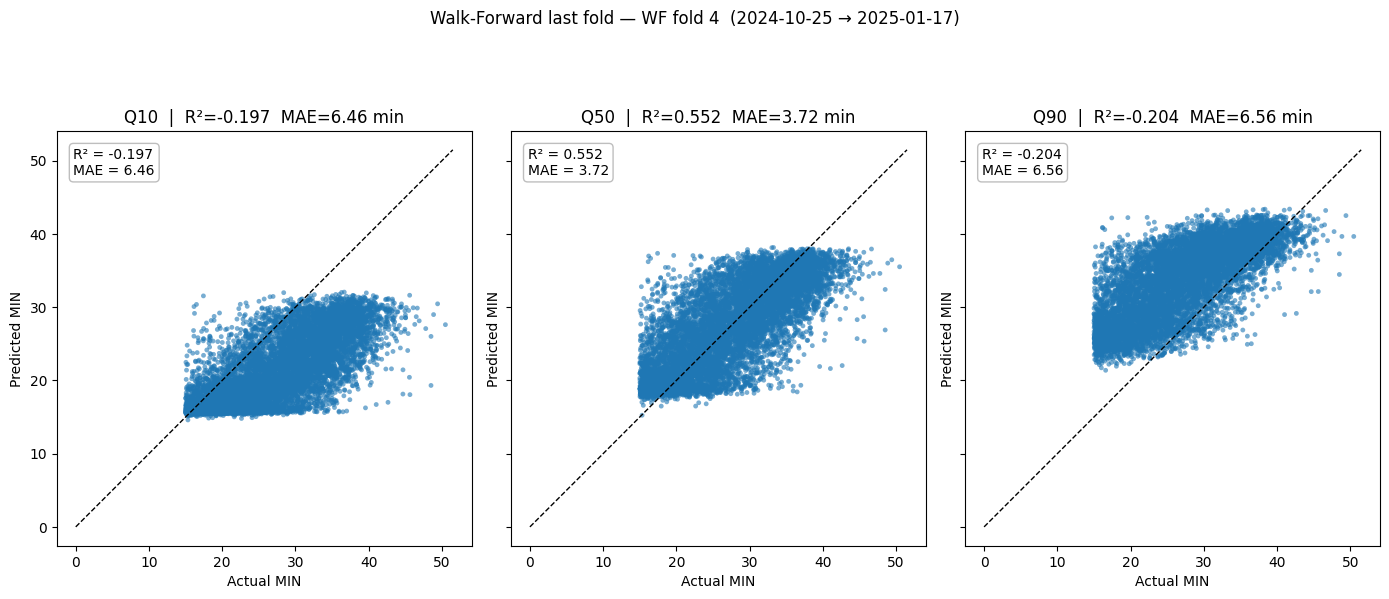

Per-quantile fit on last validation fold:
  Q10: R²=-0.197  MAE=6.462 min
  Q50: R²=+0.552  MAE=3.716 min
  Q90: R²=-0.204  MAE=6.557 min

Coverage per quantile (should match quantile value):
  Q10: 10.3%  (target 10%, delta +0.3%)  ✓
  Q50: 50.1%  (target 50%, delta +0.1%)  ✓
  Q90: 90.7%  (target 90%, delta +0.7%)  ✓

80% interval width (Q10→Q90):
  mean   : 12.22 min
  median : 12.19 min
  std    : 1.70 min


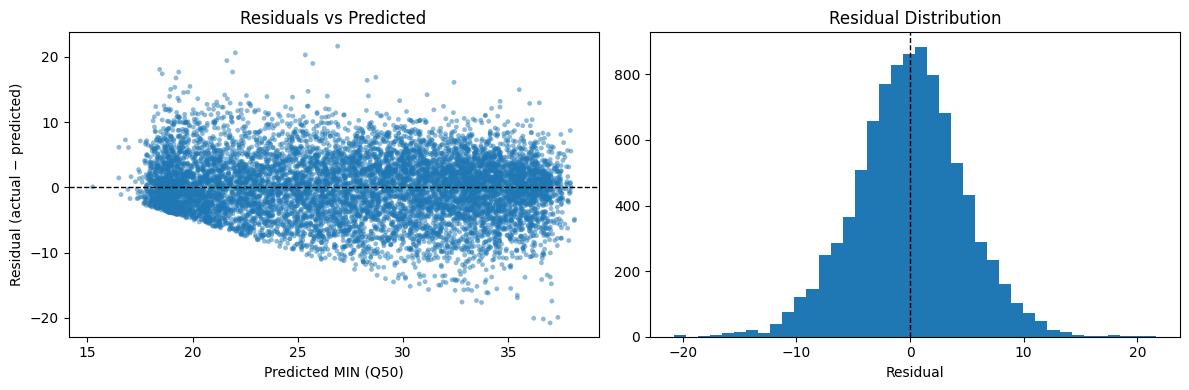


Residual summary:
  mean bias : -0.055 min  (close to 0 = unbiased)
  std       : 4.757 min

Residuals by role:
  Starters   | n= 5726 | bias=-0.403 | std=4.930
  Bench      | n= 3534 | bias=+0.510 | std=4.404

Residuals by minutes tier:
  15-24 min  | n= 3162 | bias=-3.008 | std=3.973
  24-31 min  | n= 2774 | bias=-0.212 | std=4.507
  31+ min    | n= 3324 | bias=+2.885 | std=3.756


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

y_true = y_val_last.values
pred_low = preds_last["q_0.10"]
pred_mid = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]
preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta = coverage - q_target
    flag = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.2f} min")
print(f"  median : {np.median(interval_width):.2f} min")
print(f"  std    : {interval_width.std():.2f} min")

residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")
axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

starting_last = ppm_df.loc[X_val_last.index, "starting"].values
print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")

print("\nResiduals by minutes tier:")
for tier, fn in MIN_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")



── q_0.10 ──


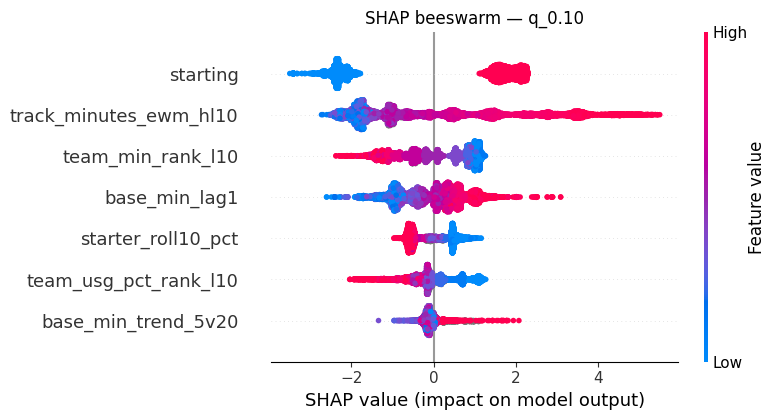


── q_0.50 ──


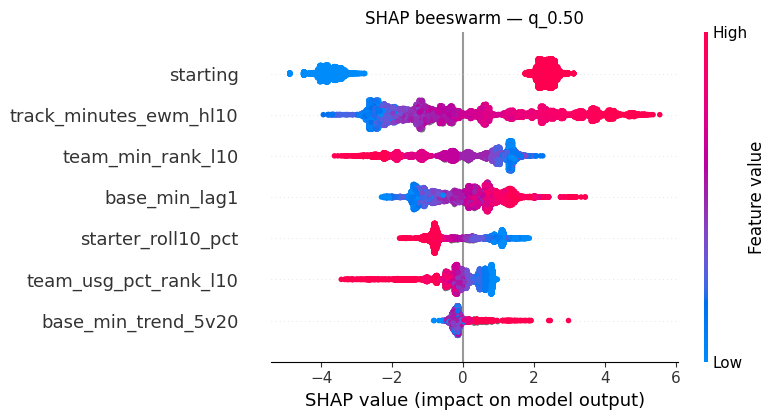


── q_0.90 ──


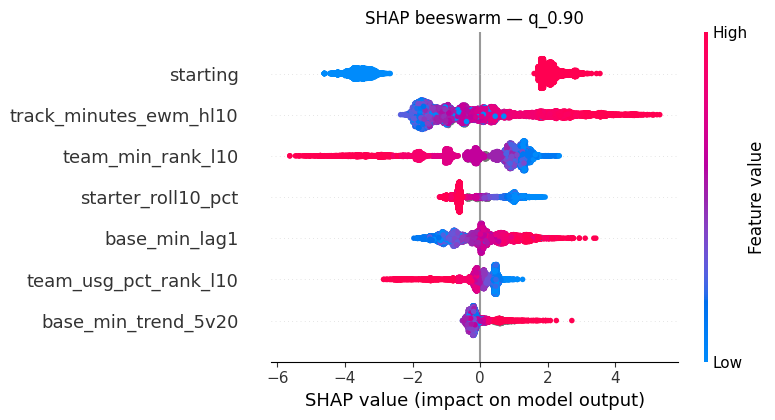

In [19]:
import shap

for q_key, model in models_last.items():
    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()


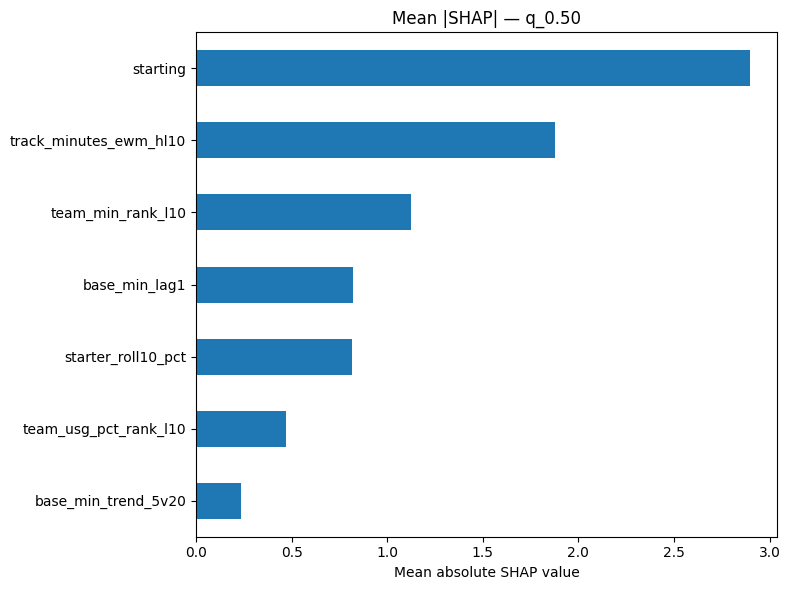

In [20]:
model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [21]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                  feature  importance      std  p_value  significant
1                starting     0.55822  0.00872      0.0         True
2  track_minutes_ewm_hl10     0.49428  0.01280      0.0         True
3       team_min_rank_l10     0.17030  0.00682      0.0         True
4      starter_roll10_pct     0.15409  0.00688      0.0         True
5           base_min_lag1     0.09396  0.00391      0.0         True
6   team_usg_pct_rank_l10     0.03703  0.00372      0.0         True
7     base_min_trend_5v20     0.00839  0.00158      0.0         True


In [22]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline RMSE (all features): 4.7572
                  feature  ablated_rmse  delta_rmse
1                starting        4.9566      0.1994
2  track_minutes_ewm_hl10        4.8704      0.1132
3           base_min_lag1        4.8035      0.0463
4      starter_roll10_pct        4.7966      0.0394
5       team_min_rank_l10        4.7774      0.0202
6   team_usg_pct_rank_l10        4.7723      0.0151
7     base_min_trend_5v20        4.7691      0.0119


In [23]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                  feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus  keep
1                starting       2.895483          1          1          0.55822              0.00872  6.148900e-54          0.1994   1.000000   1.000000   1.000000  True
2  track_minutes_ewm_hl10       1.876651          2          2          0.49428              0.01280  1.394888e-47          0.1132   0.648130   0.885457   0.766794  True
3       team_min_rank_l10       1.124983          3          3          0.17030              0.00682  4.217391e-42          0.0202   0.388530   0.305077   0.346804  True
4      starter_roll10_pct       0.817634          5          4          0.15409              0.00688  9.874208e-41          0.0394   0.282383   0.276038   0.279210  True
5           base_min_lag1       0.821393          4          5          0.09396              0.00391  1.341967e-41          0.0463   0.283681   0.1683

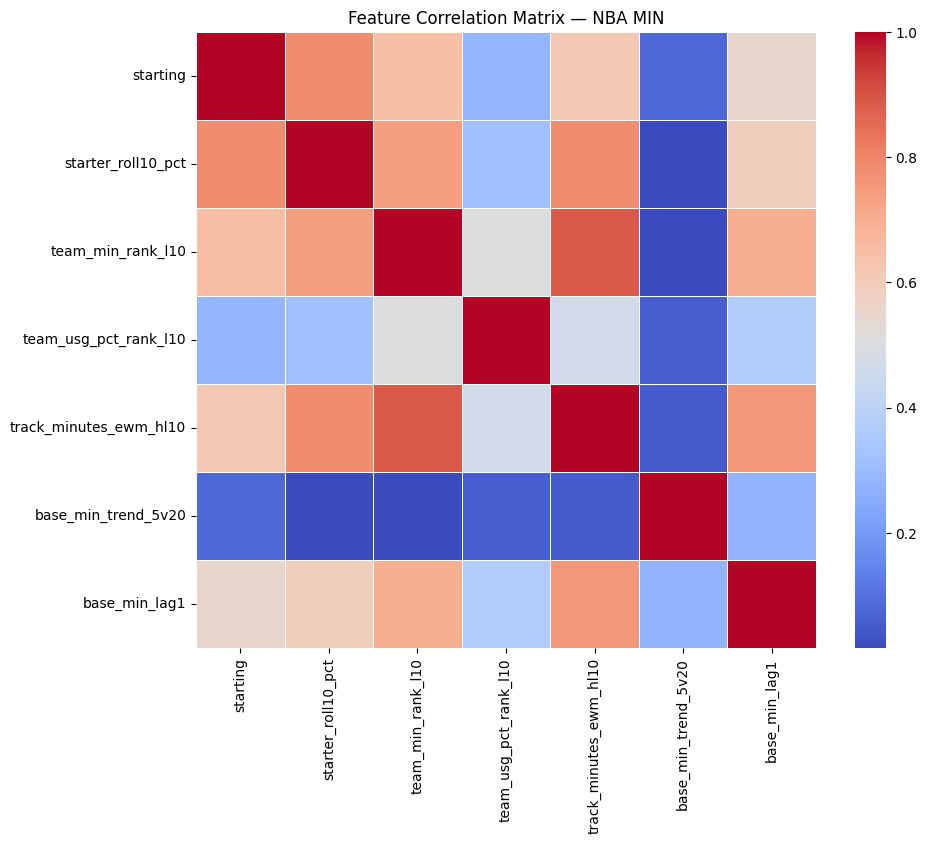

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [24]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — NBA MIN"
)
correlated_features


In [25]:
holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  Overall  | n=20095 | MAE: 3.754 | R²: 0.493 | 80% Coverage: 80.3%
  Starters   | n=12026 | MAE: 3.946 | Coverage: 81.4%
  Bench      | n= 8069 | MAE: 3.467 | Coverage: 78.6%
  15-24 min  | n= 7363 | MAE: 3.844 | Coverage: 75.2%
  24-31 min  | n= 6682 | MAE: 3.626 | Coverage: 87.4%
  31+ min    | n= 6050 | MAE: 3.786 | Coverage: 78.7%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean)  : 3.782
  Holdout MAE              : 3.754
  Gap                      : -0.028  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.6%  target: 10%  delta: +0.6%  ✓
  q_0.50 | actual coverage: 51.9%  target: 50%  delta: +1.9%  ✓
  q_0.90 | actual coverage: 90.9%  target: 90%  delta: +0.9%  ✓

Holdout 80% interval width (Q10→Q90):

In [26]:
naive_holdout_results = evaluate_holdout_vs_naive(
    ppm_holdout,
    preds_ho,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    naive_secondary=NAIVE_SECONDARY,
    naive_wf_primary=naive["naive_wf_primary"],
    wf_test_primary=naive["wf_test_primary"],
    alpha=ALPHA,
    holdout_label=f"{HOLDOUT_SEASON} holdout",
)


───────────────────────────────────────────────────────
2025-26 holdout — model vs frozen naive baselines
  H0: model does not beat naive | H1: model beats naive (α=0.05)

  PRIMARY (base_min_season_avg)
    n paired   : 19,785
    MAE model  : 3.736
    MAE naive  : 5.150
    ΔMAE (m−n) : -1.414
    Wilcoxon p : 0
    Decision   : REJECT H0 — model significantly better

  secondary (base_min_lag1)
    n paired   : 19,785
    MAE model  : 3.736
    MAE naive  : 5.633
    ΔMAE (m−n) : -1.898
    Wilcoxon p : 0
    Decision   : REJECT H0 — model significantly better


### Complexity ladder — naive → linear quantile → XGB

Report-only baseline (not shipped). Same `MIN_FEATURES` and walk-forward / holdout masks as XGB.

- **Linear:** `SimpleImputer(median)` → `StandardScaler` → `QuantileRegressor` (Q10/Q50/Q90)
- Pairwise Wilcoxon on |error|: linear vs naive, XGB vs linear (α = 0.05)
- Authoritative decision remains XGB vs frozen naive on holdout; this ladder answers “does nonlinearity buy anything?”


In [27]:
linear = run_quantile_linear_baseline(
    X, y, ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    naive_primary=NAIVE_PRIMARY,
    xgb_preds_last=preds_last,
    xgb_preds_ho=preds_ho,
    last_fold=last_fold,
    role_col=ROLE_COL,
    quantiles=QUANTILES,
    alpha=ALPHA,
    holdout_label=f"{HOLDOUT_SEASON} holdout",
)


── Quantile linear baseline (report-only) ───────────────────────────
  Features : 7
  Quantiles: [0.1, 0.5, 0.9]
  L1 alpha : 0.0

Three-way MAE by walk-forward fold:
  Fold                                             Naive   Linear      XGB     ΔL−N     ΔX−L    Cov80
  WF fold 1  (2023-01-19 → 2023-10-29)             5.346    3.926    3.782   -1.420   -0.144   79.7%
  WF fold 2  (2023-10-29 → 2024-01-22)             4.874    3.871    3.765   -1.003   -0.106   80.5%
  WF fold 3  (2024-01-22 → 2024-10-25)             5.711    4.021    3.864   -1.690   -0.157   78.6%
  WF fold 4  (2024-10-25 → 2025-01-17)             4.821    3.835    3.716   -0.986   -0.119   80.8%

────────────────────────────────────────────────────────────
Walk-forward last-fold pairwise tests:
  WF last fold: linear vs naive
    MAE challenger=3.831  baseline=4.821  Δ=-0.991  p=1.109e-103  REJECT
  WF last fold: XGB vs linear
    MAE challenger=3.716  baseline=3.835  Δ=-0.119  p=6.147e-17  REJECT

Linear | 2025-26 

In [28]:
from sklearn.metrics import mean_absolute_error

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    naive_holdout_results=naive_holdout_results,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (holdout): {mean_absolute_error(y_ho, test_preds):.3f}")
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

predict_quantiles(models_loaded, feature_names, X_ho.head(3))


Saved to /Users/alexgonzalez/Documents/NBA-Prop-Predictor/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/NBA-Prop-Predictor/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded model MAE (holdout): 3.754
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q10,q50,q90
0,21.597498,30.083899,36.850918
1,21.597498,30.083899,36.850918
2,21.597498,30.083899,36.850918
